# Movie Review Sentiment Analysis — Text Cleaning & Preprocessing

Clean the raw text (lowercase, strip URLs / punctuation / digits, remove stopwords, apply Porter stemming) and save a tidy `clean_text` + `label` dataset for modeling.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, clean_text
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Handle Missing / Duplicate Rows

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna(subset=['review', 'sentiment']).drop_duplicates().reset_index(drop=True)
print('After cleanup:', df.shape)

Missing: 0


Duplicates: 418


After cleanup: (49582, 2)


## 3. Apply Text Cleaning

In [4]:
# clean_text: lowercase, strip urls/html/punctuation/digits, remove stopwords, Porter-stem
print('Example BEFORE:'); print(repr(df['review'].iloc[0][:300]))
df['clean_text'] = df['review'].astype(str).apply(clean_text)
print('\nExample AFTER:'); print(repr(df['clean_text'].iloc[0][:300]))

Example BEFORE:
"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru"



Example AFTER:
'one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e'


## 4. Drop Rows That Became Empty After Cleaning

In [5]:
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df)} rows that were empty after cleaning')
print('Remaining:', len(df))

Dropped 0 rows that were empty after cleaning
Remaining: 49582


## 5. Cleaned Text Length Comparison

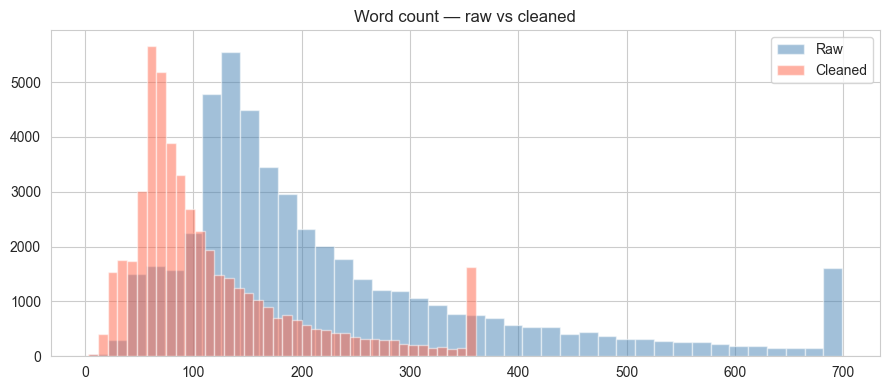

Mean words raw : 231.4
Mean words clean: 117.9


In [6]:
df['raw_words'] = df['review'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_words'].clip(upper=df['raw_words'].quantile(0.97)), bins=40, alpha=0.5, label='Raw', color='steelblue')
ax.hist(df['clean_words'].clip(upper=df['clean_words'].quantile(0.97)), bins=40, alpha=0.5, label='Cleaned', color='tomato')
ax.set_title('Word count — raw vs cleaned'); ax.legend()
plt.tight_layout(); plt.show()
print('Mean words raw :', round(df['raw_words'].mean(), 1))
print('Mean words clean:', round(df['clean_words'].mean(), 1))

## 6. Encode Label

In [7]:
# Map label to integer codes
df['label'] = df['sentiment'].astype('category')
label_mapping = dict(enumerate(df['label'].cat.categories))
df['label'] = df['label'].cat.codes
print('Label mapping:', label_mapping)

Label mapping: {0: 'negative', 1: 'positive'}


## 7. Save Cleaned Dataset

In [8]:
out = df[['clean_text', 'label']].copy()
out.to_csv('data/imdb_cleaned.csv', index=False)
print('Saved -> data/imdb_cleaned.csv', out.shape)
out.head()

Saved -> data/imdb_cleaned.csv (49582, 2)


,clean_text,label
0,one review mention watch oz episod hook right ...,1
1,wonder littl product film techniqu unassum old...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic famili littl boy jake think zombi closet...,0
4,petter mattei love time money visual stun film...,1
